# Objective To build a Convoultinal Autoencoder that compress facial images into lower-dimensional latent representation and recounstrus them with minimal loss of information

Purpose A Convolutinoal Autoencoder is an unsupervised deep learning model used for: Iamge Compression Image recostruction Feature Extraction Dimenstinality Reduction The encoder learns a compressed represetntation,While the decoder reconstructs the original image from this compressed representation

# Libraries

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil  # moving and coping files

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

# Download the dataset

In [2]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Dataset downloaded to:", path)

100%|██████████| 1.33G/1.33G [00:12<00:00, 115MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


In [3]:
# Create a Smaller Dateset (5000 Images)

source_folder = os.path.join(path,"img_align_celeba", "img_align_celeba")

destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

# Get a list of all image files in the source folder
images = sorted(os.listdir(source_folder))[:5000] # here it taking starting 5000 data

for img in images:
  shutil.copy(os.path.join(source_folder, img), destination_folder) #

print("Copied", len(img), "images")

Copied 10 images


In [6]:
# Data Preprocessing
IMAGE_SIZE = (64, 64)  # This tells TensorFlow to resize every image to 64 pixels × 64 pixels.

BATCH_SIZE = 32   # A batch is the number of images processed by the model at one time before updating its weights.

In [7]:
datagen = ImageDataGenerator(  #Reads images from a folder Preprocesses them Creates batches Optionally performs data augmentation (rotation, zoom, flip, etc.)
    rescale = 1./255,
    validation_split = 0.2
)

In [8]:
# Load Dataset
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size = IMAGE_SIZE,  # 64 * 64
    batch_size = BATCH_SIZE,
    class_mode = "input",
    subset = "training"
)


Found 4000 images belonging to 1 classes.


In [9]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "input",
    subset = "validation"
)

Found 1000 images belonging to 1 classes.


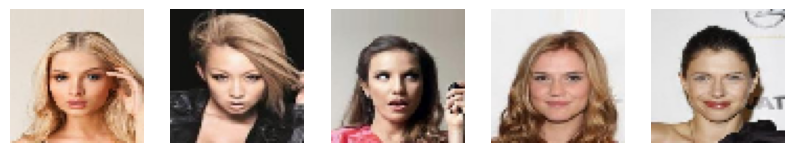

In [10]:
# Display Sample Images
images, _ = next(train_generator)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [11]:
# Build Convolutional Autoencoder
# Encoder is compress
input_img = Input(shape = (64,64,3)) # image size 3 rgb scale

x = Conv2D(   # 32 is filters (3,3) that check window size
    32,       # 64 to 32
    (3,3),
    activation = "relu",
    padding = "same"  # image size
)(input_img)

x = MaxPooling2D((2,2), padding = "same")(x)  # Maxpooling it maximum numbers in matrix (2,2) window size it check

x = Conv2D(
    64,      # here it 32, 32, 64 (64 is we increasing) it compress 32 to 16
    (3,3),     # compressing filters
    activation = "relu",
    padding = "same"
)(x)

encoded = MaxPooling2D(
    (2,2),     # here 16 to 8
    padding = "same"
)(x)

In [26]:
# Decoder
x = Conv2D(
    64,
    (3,3),
    activation = "relu",
    padding = "same"
)(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    32,
    (3,3),
    activation = "relu",
    padding = "same"
)(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    3,
    (3,3),
    activation = "sigmoid",
    padding = "same"
)(x)

In [13]:
# Create Model
autoencoder = Model(input_img, decoded)

In [14]:
# Compile Model
autoencoder.compile(
    optimizer = "adam",   # An optimizer is the algorithm that updates the neural network's weights to reduce the error (loss).
    loss = "binary_crossentropy"   # It measures the difference between your model's predicted probabilities and the actual class labels(0 and 1)
    # accurracy = "accuracy"
)

In [15]:
# Model Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train Model
history = autoencoder.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 70s 540ms/step - loss: 0.5308 - val_loss: 0.4970
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 524ms/step - loss: 0.4923 - val_loss: 0.4890
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 514ms/step - loss: 0.4877 - val_loss: 0.4864
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 521ms/step - loss: 0.4861 - val_loss: 0.4855
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 520ms/step - loss: 0.4851 - val_loss: 0.4843
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 529ms/step - loss: 0.4842 - val_loss: 0.4841
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 70s 559ms/step - loss: 0.4840 - val_loss: 0.4836
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 525ms/step - loss: 0.4837 - val_loss: 0.4836
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 526ms/step - loss: 0.4830 - val_loss: 0.4832
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 521ms/step - loss: 0.4833 - val_loss: 0.4826


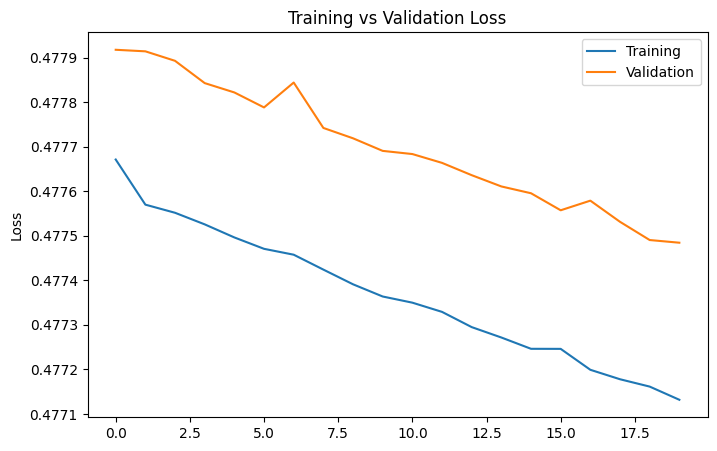

In [24]:
# Plot Loss
plt.figure(figsize = (8, 5))
plt.plot(history.history["loss"])     # TensorFlow stores the training information inside history. "The key "loss" contains the training loss after each epoch."
plt.plot(history.history["val_loss"])
plt.title("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Training", "Validation"])   # A "legend" tells us which line represents which data.
plt.show()

In [25]:
# Evaluate Model
loss = autoencoder.evaluate(validation_generator)   # evaluate() tests the trained model on the validation dataset.

print("Validation Loss :", loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - loss: 0.4775
Validation Loss : 0.4774843752384186


In [19]:
# Reconstruction Images
images, _ = next(validation_generator)   # next() takes the next batch from the generator.

reconstructed = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step


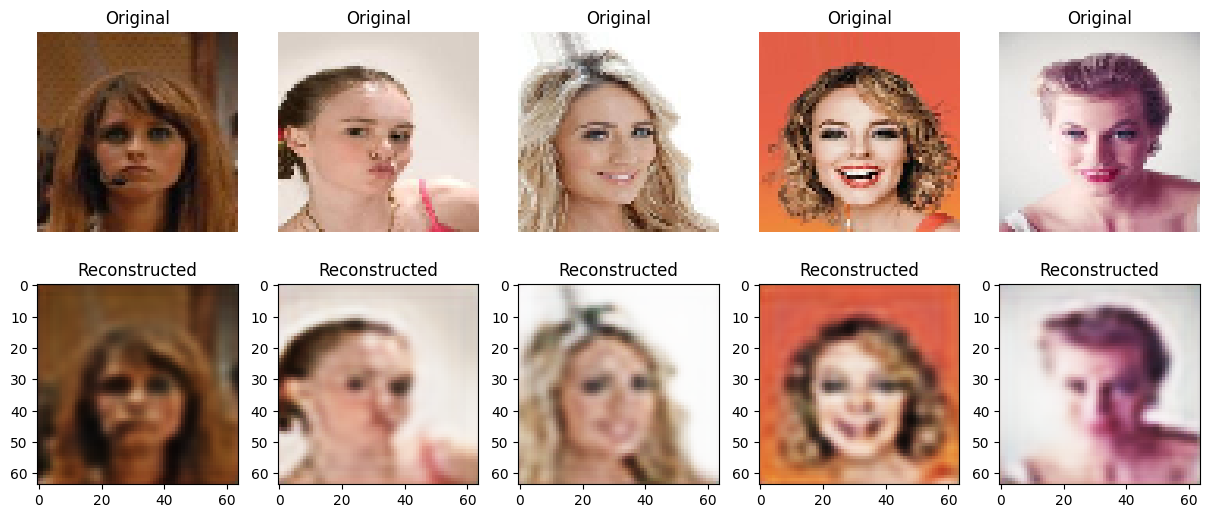

In [20]:
# Display Results
n = 5
plt.figure(figsize = (15, 6))
for i in range(n):
  plt.subplot(2, n, i + 1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2, n, n + i + 1)
  plt.imshow(reconstructed[i])
  plt.title("Reconstructed")

plt.show()

# HyperParameter without Batch_size

In [23]:
# hyper parameter
from tensorflow.keras.optimizers import Adam

learning_rates = [0.001, 0.0005, 0.0001]  # learning rates doing different learning rates

for lr in learning_rates:

    print(*40)
    print("Learning Rate:", lr)

    autoencoder.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy"
    )

    history = autoencoder.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=20,
        verbose=1
    )


Learning Rate: 0.001
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 522ms/step - loss: 0.4932 - val_loss: 0.4843
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 522ms/step - loss: 0.4831 - val_loss: 0.4832
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 521ms/step - loss: 0.4824 - val_loss: 0.4831
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 528ms/step - loss: 0.4821 - val_loss: 0.4821
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 527ms/step - loss: 0.4823 - val_loss: 0.4819
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 533ms/step - loss: 0.4827 - val_loss: 0.4821
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 535ms/step - loss: 0.4818 - val_loss: 0.4817
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 522ms/step - loss: 0.4815 - val_loss: 0.4835
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 530ms/step - loss: 0.4814 - val_loss: 0.4823
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 516ms/step - loss: 0.4814 - val_loss: 0.4814
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 84s 530ms/step - loss: 0.4809 - val_loss: 0.481

# Loss accuracy

In [27]:
loss = autoencoder.evaluate(validation_generator, verbose=0)

print("Validation Loss:", loss)

Validation Loss: 0.47748440504074097


# HyperParameter With Batch_size here Creating a new batch

In [28]:
learning_rates = [0.001] # hyperparameter learning rate
batch_sizes = [64] # epochs batch_size i used 64

for batch in batch_sizes:
    train_generator = datagen.flow_from_directory(
        "celeba_small",
        target_size=IMAGE_SIZE,
        batch_size=batch,
        class_mode="input",
        subset="training"
    )

    validation_generator = datagen.flow_from_directory(
        "celeba_small",
        target_size=IMAGE_SIZE,
        batch_size=batch,
        class_mode="input",
        subset="validation"
    )

    for lr in learning_rates:
        autoencoder.compile(
            optimizer=Adam(learning_rate=lr),
            loss="binary_crossentropy"
        )

        autoencoder.fit(
            train_generator,
            validation_data=validation_generator,
            epochs=10
        )

Found 4000 images belonging to 1 classes.
Found 1000 images belonging to 1 classes.
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 0.5182 - val_loss: 0.4849
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 0.4823 - val_loss: 0.4815
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 0.4804 - val_loss: 0.4804
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.4796 - val_loss: 0.4797
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.4792 - val_loss: 0.4794
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.4789 - val_loss: 0.4792
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.4786 - val_loss: 0.4789
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.4785 - val_loss: 0.4789
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - loss: 0.4784 - val_loss: 0.4787
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - loss: 0.4782 - val_loss: 0.4785


In [29]:
loss = autoencoder.evaluate(validation_generator, verbose=0)

print("Validation Loss:", loss)

Validation Loss: 0.4785440266132355
